In [1]:
!pip install transformers datasets accelerate -q

import torch
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

✅ PyTorch version: 2.8.0+cu126
✅ CUDA available: True
✅ GPU: Tesla T4


In [5]:
from google.colab import drive

# Unmount if partially mounted
try:
    drive.flush_and_unmount()
    print("Unmounted previous session")
except:
    pass

# Mount fresh
print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

print("\n✅ Drive mounted!")

# Verify mount
import os
print("\nVerifying mount...")
print("Contents of /content/:")
print(os.listdir('/content/'))

if os.path.exists('/content/drive'):
    print("\n✅ /content/drive exists!")
    print("Contents:")
    print(os.listdir('/content/drive'))

Drive not mounted, so nothing to flush and unmount.
Unmounted previous session
Mounting Google Drive...
Mounted at /content/drive

✅ Drive mounted!

Verifying mount...
Contents of /content/:
['.config', 'drive', 'sample_data']

✅ /content/drive exists!
Contents:
['.shortcut-targets-by-id', 'Othercomputers', 'MyDrive', '.Trash-0', '.Encrypted']


In [10]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print("\n✅ All libraries imported successfully!")

Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB

✅ All libraries imported successfully!


In [11]:
import pandas as pd

# Load from Google Drive (not /content/truthlens)
df = pd.read_csv('/content/drive/MyDrive/TruthLens/data/cleaned_news_data.csv')

print(f"✅ Data loaded: {df.shape}")
print(f"\nClass distribution:")
print(df['label'].value_counts())

✅ Data loaded: (43944, 7)

Class distribution:
label
0    22528
1    21416
Name: count, dtype: int64


In [12]:
X = df['text']
y = df['label']

print(f"\nUsing original text for BERT training")
print(f"Features (X): {X.shape}")
print(f"Labels (y): {y.shape}")

df.head()


Using original text for BERT training
Features (X): (43944,)
Labels (y): (43944,)


,title,text,cleaned_title,cleaned_text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,donald trump sends embarrassing new year ’ eve...,donald trump wish american happy new year leav...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",sheriff david clarke becomes internet joke thr...,friday revealed former milwaukee sheriff david...,News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",trump obsessed even obama ’ name coded website...,christmas day donald trump announced would bac...,News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,pope francis called donald trump christmas speech,pope francis used annual christmas day message...,News,"December 25, 2017",0


In [13]:
# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second split: 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("="*60)
print("DATA SPLIT")
print("="*60)
print(f"Training set: {len(X_train)} samples (80%)")
print(f"Validation set: {len(X_val)} samples (10%)")
print(f"Test set: {len(X_test)} samples (10%)")

print(f"\nTraining distribution:")
print(y_train.value_counts())
print(f"\nValidation distribution:")
print(y_val.value_counts())
print(f"\nTest distribution:")
print(y_test.value_counts())

DATA SPLIT
Training set: 35155 samples (80%)
Validation set: 4394 samples (10%)
Test set: 4395 samples (10%)

Training distribution:
label
0    18022
1    17133
Name: count, dtype: int64

Validation distribution:
label
0    2253
1    2141
Name: count, dtype: int64

Test distribution:
label
0    2253
1    2142
Name: count, dtype: int64


In [14]:
# Load DistilBERT tokenizer
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)

print(f"✅ Tokenizer loaded: {model_name}")
print(f"Vocab size: {tokenizer.vocab_size}")

# Test tokenization
sample_text = X_train.iloc[0]
tokens = tokenizer(sample_text, truncation=True, padding=True, max_length=512)

print(f"\nSample text (first 200 chars):")
print(sample_text[:200])
print(f"\nTokenized (first 20 tokens):")
print(tokens['input_ids'][:20])
print(f"\nTotal tokens: {len(tokens['input_ids'])}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

✅ Tokenizer loaded: distilbert-base-uncased
Vocab size: 30522

Sample text (first 200 chars):
Obama just couldn t keep quiet. He released a statement via Facebook today lashing out at President Trump s decision to rescind his DACA executive action, labeling the move as  cruel  in an immediate 

Tokenized (first 20 tokens):
[101, 8112, 2074, 2481, 1056, 2562, 4251, 1012, 2002, 2207, 1037, 4861, 3081, 9130, 2651, 25210, 2075, 2041, 2012, 2343]

Total tokens: 512


In [15]:
print("Tokenizing dataset...")
print("This may take 5-10 minutes for 44k articles...")

def tokenize_function(examples):
    """Tokenize text with truncation and padding"""
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=512  # DistilBERT max length
    )

# Create datasets
train_dataset = Dataset.from_dict({
    'text': X_train.values,
    'label': y_train.values
})

val_dataset = Dataset.from_dict({
    'text': X_val.values,
    'label': y_val.values
})

test_dataset = Dataset.from_dict({
    'text': X_test.values,
    'label': y_test.values
})

# Tokenize
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print(f"✅ Tokenization complete!")
print(f"\nTrain dataset: {len(train_dataset)}")
print(f"Val dataset: {len(val_dataset)}")
print(f"Test dataset: {len(test_dataset)}")

Tokenizing dataset...
This may take 5-10 minutes for 44k articles...


Map:   0%|          | 0/35155 [00:00<?, ? examples/s]

Map:   0%|          | 0/4394 [00:00<?, ? examples/s]

Map:   0%|          | 0/4395 [00:00<?, ? examples/s]

✅ Tokenization complete!

Train dataset: 35155
Val dataset: 4394
Test dataset: 4395


In [16]:
# Load DistilBERT for binary classification
model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2  # Binary classification: Fake (0) or True (1)
)

# Move model to GPU if available
model.to(device)

print(f"✅ Model loaded: {model_name}")
print(f"Number of parameters: {model.num_parameters():,}")
print(f"Model size: {model.num_parameters() * 4 / (1024**2):.2f} MB")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded: distilbert-base-uncased
Number of parameters: 66,955,010
Model size: 255.41 MB


In [17]:
# Define training arguments
training_args = TrainingArguments(
    output_dir='../models/distilbert_checkpoints',
    num_train_epochs=3,              # 3 epochs should be enough
    per_device_train_batch_size=16,  # Adjust based on GPU memory
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='../models/logs',
    logging_steps=100,
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    save_total_limit=2,              # Keep only 2 best checkpoints
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
    report_to='none',                # Disable wandb/tensorboard
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
)

print("✅ Training arguments configured")
print(f"\nTraining configuration:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Train batch size: {training_args.per_device_train_batch_size}")
print(f"  Eval batch size: {training_args.per_device_eval_batch_size}")
print(f"  Mixed precision (FP16): {training_args.fp16}")

✅ Training arguments configured

Training configuration:
  Epochs: 3
  Train batch size: 16
  Eval batch size: 32
  Mixed precision (FP16): True


In [18]:
def compute_metrics(pred):
    """Compute accuracy, precision, recall, F1"""
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("✅ Metrics function defined")

✅ Metrics function defined


In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✅ Trainer initialized")


✅ Trainer initialized


In [20]:
print("="*60)
print("STARTING TRAINING")
print("="*60)
print("This will take some time...")
print("You can monitor progress below\n")

# Train the model
train_result = trainer.train()

print("\n✅ Training complete!")
print(f"\nTraining metrics:")
print(f"  Final loss: {train_result.training_loss:.4f}")
print(f"  Training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"  Samples per second: {train_result.metrics['train_samples_per_second']:.2f}")

STARTING TRAINING
This will take some time...
You can monitor progress below



Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
500,0.017900,0.001688,0.999772,1.000000,0.999533,0.999766
1000,0.005400,0.008545,0.997724,0.995351,1.000000,0.997670
1500,0.000100,0.000094,1.000000,1.000000,1.000000,1.000000
2000,0.001400,0.000022,1.000000,1.000000,1.000000,1.000000
2500,0.000000,0.000023,1.000000,1.000000,1.000000,1.000000
3000,0.000000,0.000009,1.000000,1.000000,1.000000,1.000000



✅ Training complete!

Training metrics:
  Final loss: 0.0209
  Training time: 900.63 seconds
  Samples per second: 117.10


In [21]:
print("="*60)
print("VALIDATION SET EVALUATION")
print("="*60)

# Evaluate on validation set
val_results = trainer.evaluate(eval_dataset=val_dataset)

print(f"\nValidation Metrics:")
print(f"  Accuracy:  {val_results['eval_accuracy']:.4f} ({val_results['eval_accuracy']*100:.2f}%)")
print(f"  Precision: {val_results['eval_precision']:.4f}")
print(f"  Recall:    {val_results['eval_recall']:.4f}")
print(f"  F1 Score:  {val_results['eval_f1']:.4f}")
print(f"  Loss:      {val_results['eval_loss']:.4f}")

VALIDATION SET EVALUATION



Validation Metrics:
  Accuracy:  1.0000 (100.00%)
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000
  Loss:      0.0001


In [22]:
print("="*60)
print("TEST SET EVALUATION")
print("="*60)

# Get predictions on test set
predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)
y_pred_proba = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print(f"\nTest Set Metrics:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  ROC AUC:   {roc_auc:.4f}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))

TEST SET EVALUATION



Test Set Metrics:
  Accuracy:  0.9995 (99.95%)
  Precision: 0.9991
  Recall:    1.0000
  F1 Score:  0.9995
  ROC AUC:   1.0000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2253
        True       1.00      1.00      1.00      2142

    accuracy                           1.00      4395
   macro avg       1.00      1.00      1.00      4395
weighted avg       1.00      1.00      1.00      4395



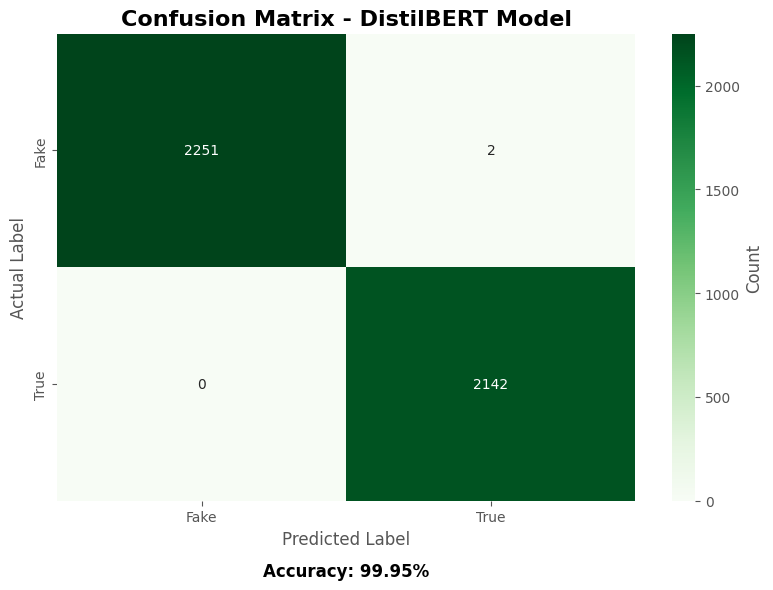


True Negatives (Correct Fake): 2251
False Positives (Fake predicted as True): 2
False Negatives (True predicted as Fake): 0
True Positives (Correct True): 2142


In [23]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fake', 'True'],
            yticklabels=['Fake', 'True'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - DistilBERT Model', fontsize=16, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# Add accuracy text
accuracy_text = f'Accuracy: {accuracy:.2%}'
plt.text(0.5, -0.15, accuracy_text,
         ha='center', va='center',
         transform=ax.transAxes,
         fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (Correct Fake): {cm[0,0]}")
print(f"False Positives (Fake predicted as True): {cm[0,1]}")
print(f"False Negatives (True predicted as Fake): {cm[1,0]}")
print(f"True Positives (Correct True): {cm[1,1]}")

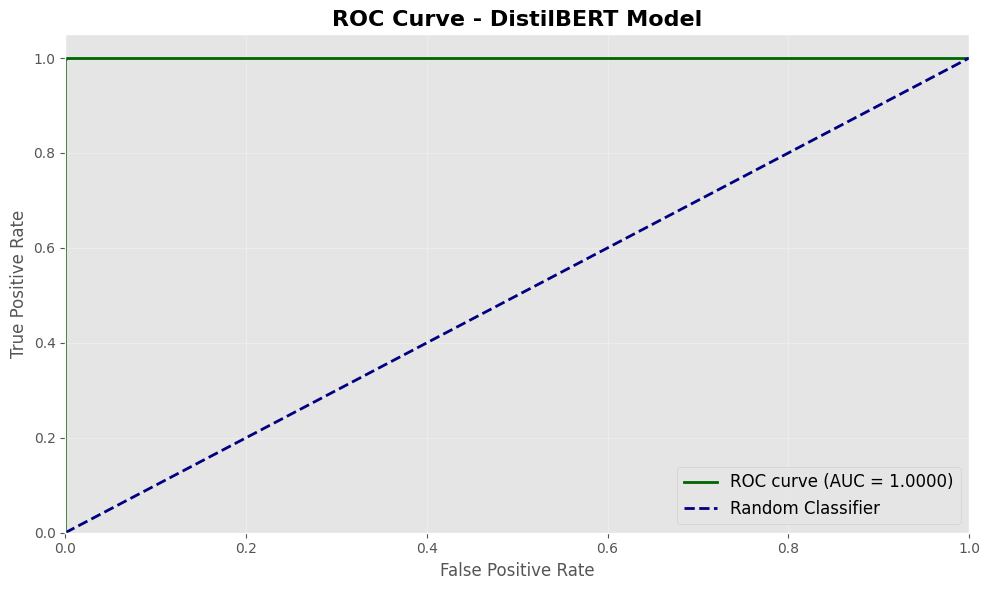

In [24]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkgreen', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - DistilBERT Model', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

MODEL COMPARISON
  Metric  Baseline (TF-IDF + LR)  DistilBERT
Accuracy                  0.9884    0.999545
F1 Score                  0.9881    0.999533
 ROC AUC                  0.9986    1.000000


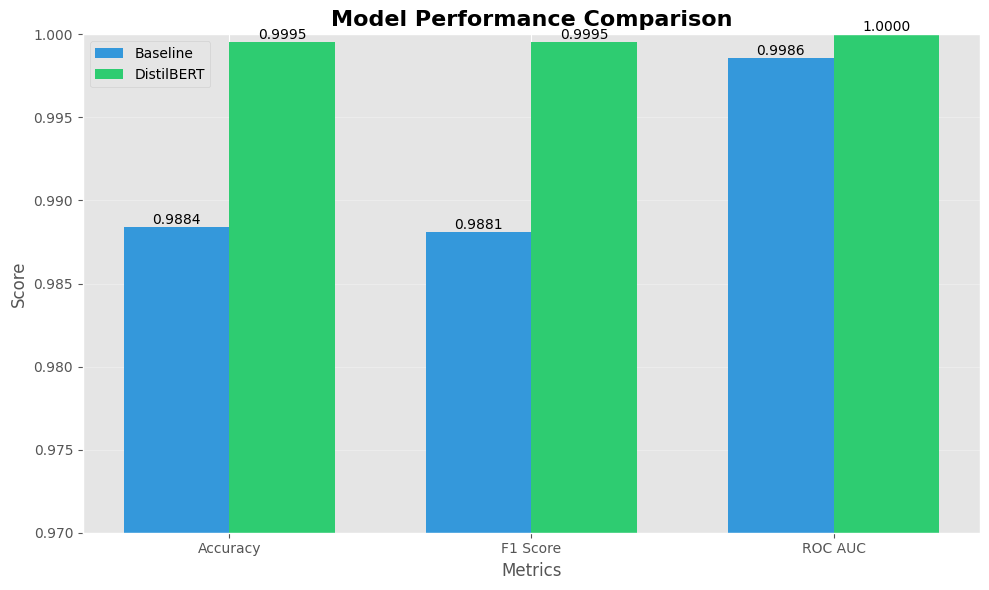

In [25]:
# Baseline metrics (from your results)
baseline_accuracy = 0.9884
baseline_f1 = 0.9881
baseline_roc_auc = 0.9986

# DistilBERT metrics
distilbert_accuracy = accuracy
distilbert_f1 = f1
distilbert_roc_auc = roc_auc

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'ROC AUC'],
    'Baseline (TF-IDF + LR)': [baseline_accuracy, baseline_f1, baseline_roc_auc],
    'DistilBERT': [distilbert_accuracy, distilbert_f1, distilbert_roc_auc]
})

print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Baseline (TF-IDF + LR)'],
               width, label='Baseline', color='#3498db')
bars2 = ax.bar(x + width/2, comparison_df['DistilBERT'],
               width, label='DistilBERT', color='#2ecc71')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.legend()
ax.set_ylim([0.97, 1.0])  # Focus on the differences
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [26]:
def predict_with_distilbert(text):
    """Predict using DistilBERT model"""
    # Tokenize
    inputs = tokenizer(text, truncation=True, padding=True,
                      max_length=512, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1).item()

    return {
        'prediction': 'TRUE' if prediction == 1 else 'FAKE',
        'confidence': probs[0][prediction].item() * 100,
        'probabilities': {
            'fake': probs[0][0].item() * 100,
            'true': probs[0][1].item() * 100
        }
    }

# Test on a sample from test set
sample_idx = 0
sample_text = X_test.iloc[sample_idx]
sample_label = y_test.iloc[sample_idx]

result = predict_with_distilbert(sample_text)

print("="*60)
print("SAMPLE PREDICTION")
print("="*60)
print(f"\nArticle (first 400 chars):")
print(sample_text[:400] + "...")
print(f"\nActual Label: {'TRUE' if sample_label==1 else 'FAKE'}")
print(f"\nPredicted: {result['prediction']}")
print(f"Confidence: {result['confidence']:.2f}%")
print(f"\nProbabilities:")
print(f"  Fake: {result['probabilities']['fake']:.2f}%")
print(f"  True: {result['probabilities']['true']:.2f}%")

SAMPLE PREDICTION

Article (first 400 chars):
WASHINGTON (Reuters) - Former U.S. Republican presidential candidate Marco Rubio said on Thursday he would not be anybody’s running-mate in the Nov. 8 presidential election, slamming down rumors that he was seeking the vice presidential nod from former rivals.  “No, I’m not going to be anybody’s vice president... I’m not interested in being vice president,” Rubio told reporters on Capitol Hill.  R...

Actual Label: TRUE

Predicted: TRUE
Confidence: 100.00%

Probabilities:
  Fake: 0.00%
  True: 100.00%


In [27]:
import os

model.save_pretrained('/content/drive/MyDrive/TruthLens_Models/distilbert_final')
tokenizer.save_pretrained('/content/drive/MyDrive/TruthLens_Models/distilbert_final')

print("✅ Model saved to Google Drive!")

✅ Model saved to Google Drive!
